In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/MachineLearningCSV"

import os
print("Files found:", os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found: ['Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [ ]:
import glob, gc, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
OUTPUT_DIR = "hybrid_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

KNOWN_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",                        # BENIGN only
    "Tuesday-WorkingHours.pcap_ISCX.csv",                        # + Brute Force
    "Wednesday-workingHours.pcap_ISCX.csv",                      # + DoS variants
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",          # + DDoS
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",      # + PortScan
]

ZERODAY_FILES = [
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",       # Web Attacks
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",  # Infiltration
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",                    # Bot
]

In [ ]:
def load_files(data_dir, filenames, per_file_cap=None):
    frames = []
    for fname in filenames:
        path = os.path.join(data_dir, fname)
        if not os.path.exists(path):
            print(f"  [skip] {fname} not found in {data_dir}")
            continue
        df = pd.read_csv(path, low_memory=False, encoding="latin1")
        df.columns = [c.strip() for c in df.columns]
        num_cols = df.select_dtypes(include=[np.number]).columns
        df[num_cols] = df[num_cols].astype(np.float32)

        if per_file_cap and len(df) > per_file_cap:
            try:
                df, _ = train_test_split(
                    df, train_size=per_file_cap, stratify=df["Label"],
                    random_state=RANDOM_STATE
                )
            except ValueError:
                df = df.sample(per_file_cap, random_state=RANDOM_STATE)

        print(f"  - {fname:55s} kept {df.shape} | labels: "
              f"{df['Label'].value_counts().to_dict()}")
        frames.append(df)
        del df
        gc.collect()

    data = pd.concat(frames, ignore_index=True)
    del frames
    gc.collect()
    return data


def clean(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

In [ ]:
DATA_DIR = "/content/drive/MyDrive/MachineLearningCSV"
PER_FILE_CAP = 40000   # None = use full files (needs more RAM/time)

print("Loading KNOWN-attack files (used for training)...")
known_df = load_files(DATA_DIR, KNOWN_FILES, per_file_cap=PER_FILE_CAP)
known_df = clean(known_df)
print(f"\nKnown-file dataset: {known_df.shape}")

print("\nLoading ZERO-DAY files (held out entirely from training)...")
zeroday_df = load_files(DATA_DIR, ZERODAY_FILES, per_file_cap=None)
zeroday_df = clean(zeroday_df)
print(f"\nZero-day dataset: {zeroday_df.shape}")

# Align columns and drop constant columns
common_cols = [c for c in known_df.columns if c in zeroday_df.columns]
known_df = known_df[common_cols]
zeroday_df = zeroday_df[common_cols]

numeric_cols = known_df.select_dtypes(include=[np.number]).columns.tolist()
constant_cols = [c for c in numeric_cols if known_df[c].nunique() <= 1]
known_df.drop(columns=constant_cols, inplace=True)
zeroday_df.drop(columns=constant_cols, inplace=True)
print(f"\nDropped {len(constant_cols)} constant columns")

# Build binary labels
y_known = known_df["Label"].apply(lambda v: 0 if str(v).strip().upper() == "BENIGN" else 1)
X_known = known_df.drop(columns=["Label"]).select_dtypes(include=[np.number])

zeroday_raw_labels = zeroday_df["Label"]
y_zeroday = zeroday_df["Label"].apply(lambda v: 0 if str(v).strip().upper() == "BENIGN" else 1)
X_zeroday = zeroday_df.drop(columns=["Label"]).select_dtypes(include=[np.number])

print(f"\nKnown set    -> BENIGN: {(y_known==0).sum()}, ATTACK: {(y_known==1).sum()}")
print(f"Zero-day set -> BENIGN: {(y_zeroday==0).sum()}, ATTACK (unseen types): {(y_zeroday==1).sum()}")

Loading KNOWN-attack files (used for training)...
  - Monday-WorkingHours.pcap_ISCX.csv                       kept (40000, 79) | labels: {'BENIGN': 40000}
  - Tuesday-WorkingHours.pcap_ISCX.csv                      kept (40000, 79) | labels: {'BENIGN': 38759, 'FTP-Patator': 712, 'SSH-Patator': 529}
  - Wednesday-workingHours.pcap_ISCX.csv                    kept (40000, 79) | labels: {'BENIGN': 25409, 'DoS Hulk': 13343, 'DoS GoldenEye': 594, 'DoS slowloris': 335, 'DoS Slowhttptest': 318, 'Heartbleed': 1}
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        kept (40000, 79) | labels: {'DDoS': 22685, 'BENIGN': 17315}
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    kept (40000, 79) | labels: {'PortScan': 22192, 'BENIGN': 17808}

Known-file dataset: (190640, 79)

Loading ZERO-DAY files (held out entirely from training)...
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  kept (170366, 79) | labels: {'BENIGN': 168186, 'Web Attack ï¿½ Brute Force': 1507, 'Web Att

In [ ]:
X_train, X_test_known, y_train, y_test_known = train_test_split(
    X_known, y_known, test_size=0.25, stratify=y_known, random_state=RANDOM_STATE
)

# Feature selection (fit on training data only) -- used for Stage 2 (supervised)
TOP_K_FEATURES = 15
k = min(TOP_K_FEATURES, X_train.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X_train, y_train)
selected_cols = X_train.columns[selector.get_support()]
print(f"Selected {k} features: {list(selected_cols)}")

X_train_selected = X_train[selected_cols]
X_test_known_selected = X_test_known[selected_cols]
X_zeroday_selected = X_zeroday[selected_cols]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_selected)
X_test_known_s = scaler.transform(X_test_known_selected)
X_zeroday_s = scaler.transform(X_zeroday_selected)

# Stage 1 (anomaly detector) uses the FULL feature set -- features selected
# to separate benign from *known* attacks aren't necessarily what makes a
# *novel* attack look unusual.
scaler_full = StandardScaler()
X_train_full_s = scaler_full.fit_transform(X_train)
X_test_known_full_s = scaler_full.transform(X_test_known)
X_zeroday_full_s = scaler_full.transform(X_zeroday)

Selected 15 features: ['Destination Port', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward']


In [ ]:
print("Training Stage 1: Isolation Forest (benign-only, full feature set)...")
benign_mask = (y_train.values == 0)
iso = IsolationForest(
    n_estimators=200, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1
)
iso.fit(X_train_full_s[benign_mask])

def anomaly_flag(X_scaled_full):
    return (iso.predict(X_scaled_full) == -1).astype(int)   # -1 = anomaly

print("Training Stage 2: Random Forest classifier (supervised)...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20, n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train_s, y_train)

def supervised_flag(X_scaled_selected):
    return rf.predict(X_scaled_selected)

def hybrid_flag(X_scaled_selected, X_scaled_full):
    return np.maximum(anomaly_flag(X_scaled_full), supervised_flag(X_scaled_selected))

Training Stage 1: Isolation Forest (benign-only, full feature set)...
Training Stage 2: Random Forest classifier (supervised)...


=== RESULTS on KNOWN attack types (held-out test split) ===
Supervised-only    | Precision: 0.9977  Recall: 0.9942  F1: 0.9959
Hybrid             | Precision: 0.8924  Recall: 0.9942  F1: 0.9406

=== RESULTS on ZERO-DAY attack types (never seen during training) ===
Supervised-only    | Precision: 0.0006  Recall: 0.0002  F1: 0.0003
Hybrid             | Precision: 0.0080  Recall: 0.0390  F1: 0.0133


,Test Set,Method,Precision,Recall,F1-Score
0,Known Attacks,Supervised-only,0.997730,0.994162,0.995943
1,Known Attacks,Hybrid,0.892434,0.994162,0.940555
2,Zero-Day Attacks,Supervised-only,0.000579,0.000242,0.000342
3,Zero-Day Attacks,Hybrid,0.008012,0.039011,0.013294


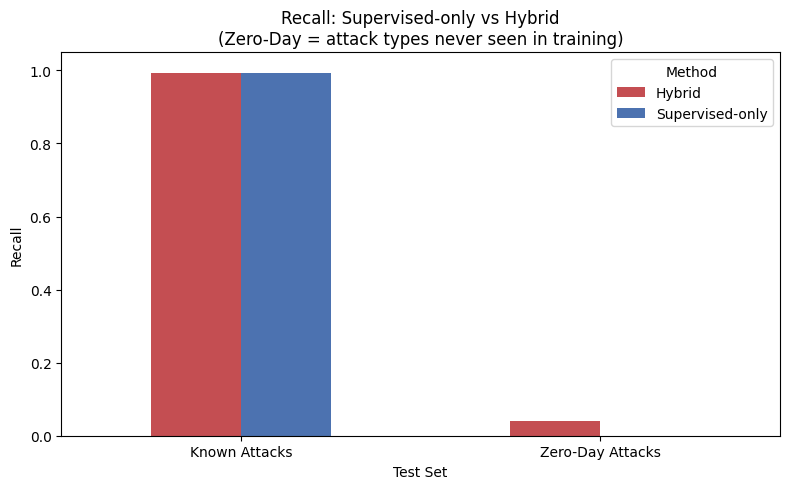

In [ ]:
results = []

print("=== RESULTS on KNOWN attack types (held-out test split) ===")
for name, pred in [
    ("Supervised-only", supervised_flag(X_test_known_s)),
    ("Hybrid", hybrid_flag(X_test_known_s, X_test_known_full_s)),
]:
    row = {
        "Test Set": "Known Attacks", "Method": name,
        "Precision": precision_score(y_test_known, pred, zero_division=0),
        "Recall": recall_score(y_test_known, pred, zero_division=0),
        "F1-Score": f1_score(y_test_known, pred, zero_division=0),
    }
    results.append(row)
    print(f"{name:18s} | Precision: {row['Precision']:.4f}  Recall: {row['Recall']:.4f}  F1: {row['F1-Score']:.4f}")

print("\n=== RESULTS on ZERO-DAY attack types (never seen during training) ===")
for name, pred in [
    ("Supervised-only", supervised_flag(X_zeroday_s)),
    ("Hybrid", hybrid_flag(X_zeroday_s, X_zeroday_full_s)),
]:
    row = {
        "Test Set": "Zero-Day Attacks", "Method": name,
        "Precision": precision_score(y_zeroday, pred, zero_division=0),
        "Recall": recall_score(y_zeroday, pred, zero_division=0),
        "F1-Score": f1_score(y_zeroday, pred, zero_division=0),
    }
    results.append(row)
    print(f"{name:18s} | Precision: {row['Precision']:.4f}  Recall: {row['Recall']:.4f}  F1: {row['F1-Score']:.4f}")

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv(os.path.join(OUTPUT_DIR, "hybrid_vs_supervised_results.csv"), index=False)

# Recall comparison chart
plt.figure(figsize=(8, 5))
pivot = results_df.pivot(index="Test Set", columns="Method", values="Recall")
pivot = pivot.reindex(["Known Attacks", "Zero-Day Attacks"])
pivot.plot(kind="bar", ax=plt.gca(), color=["#C44E52", "#4C72B0"])
plt.title("Recall: Supervised-only vs Hybrid\n(Zero-Day = attack types never seen in training)")
plt.ylabel("Recall"); plt.ylim(0, 1.05); plt.xticks(rotation=0)
plt.legend(title="Method"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "recall_comparison.png"), dpi=150)
plt.show()

,count,supervised_recall,anomaly_only_recall,hybrid_recall
true_label,,,,
BENIGN,586653,0.0029,0.0310,0.0340
Bot,1948,0.0000,0.0226,0.0226
Infiltration,36,0.0000,0.7778,0.7778
Web Attack - Brute Force,1470,0.0000,0.0490,0.0490
Web Attack - SQL Injection,21,0.0476,0.0000,0.0476
Web Attack - XSS,652,0.0000,0.0245,0.0245


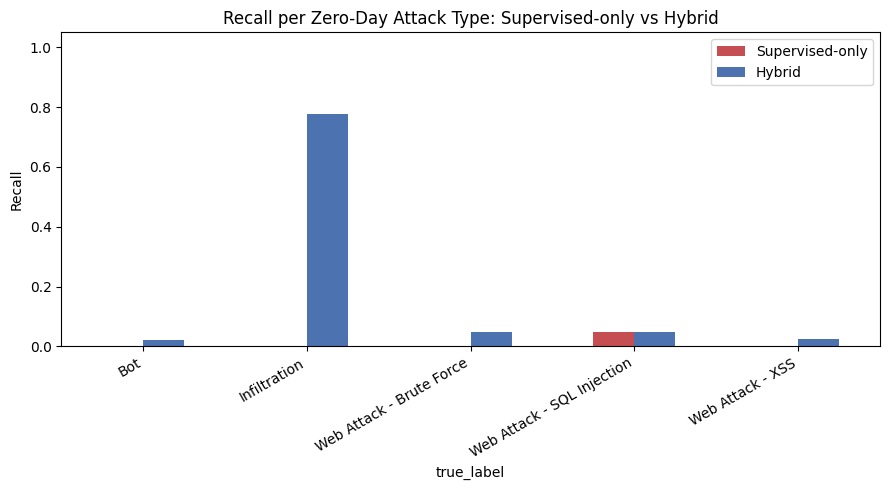

In [ ]:
# Clean up mojibake in Web Attack labels (an encoding artifact in the
# original CICIDS2017 CSV release -- en-dash saved as latin1)
clean_labels = zeroday_raw_labels.str.replace(
    r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True
).str.replace(
    r"Web Attack.*Sql Injection", "Web Attack - SQL Injection", regex=True
).str.replace(
    r"Web Attack.*XSS", "Web Attack - XSS", regex=True
)

sup_pred_zd = supervised_flag(X_zeroday_s)
anom_pred_zd = anomaly_flag(X_zeroday_full_s)
hybrid_pred_zd = np.maximum(sup_pred_zd, anom_pred_zd)

breakdown = pd.DataFrame({
    "true_label": clean_labels.values,
    "supervised_flag": sup_pred_zd,
    "anomaly_flag": anom_pred_zd,
    "hybrid_flag": hybrid_pred_zd,
})
per_type = breakdown.groupby("true_label").agg(
    count=("true_label", "size"),
    supervised_recall=("supervised_flag", "mean"),
    anomaly_only_recall=("anomaly_flag", "mean"),
    hybrid_recall=("hybrid_flag", "mean"),
).round(4)

display(per_type)
per_type.to_csv(os.path.join(OUTPUT_DIR, "per_attack_type_zeroday_recall.csv"))

plot_df = per_type.drop(index="BENIGN", errors="ignore")[["supervised_recall", "hybrid_recall"]]
plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar", ax=plt.gca(), color=["#C44E52", "#4C72B0"])
plt.title("Recall per Zero-Day Attack Type: Supervised-only vs Hybrid")
plt.ylabel("Recall"); plt.ylim(0, 1.05); plt.xticks(rotation=30, ha="right")
plt.legend(["Supervised-only", "Hybrid"]); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_attack_type_recall.png"), dpi=150)
plt.show()

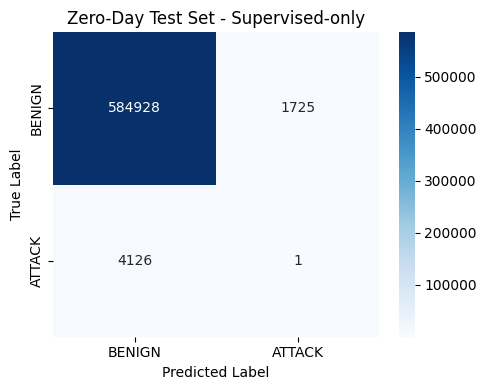

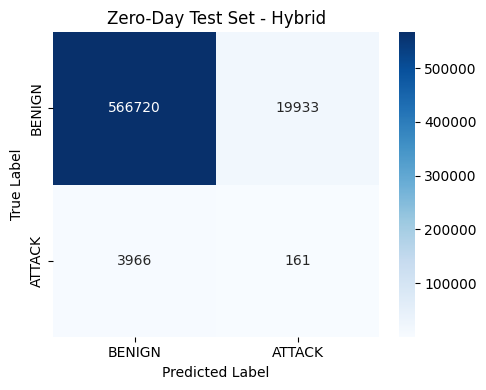


All outputs saved to: /content/hybrid_outputs


In [ ]:
for name, pred in [
    ("Supervised-only", supervised_flag(X_zeroday_s)),
    ("Hybrid", hybrid_flag(X_zeroday_s, X_zeroday_full_s)),
]:
    cm = confusion_matrix(y_zeroday, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["BENIGN", "ATTACK"], yticklabels=["BENIGN", "ATTACK"])
    plt.title(f"Zero-Day Test Set - {name}")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_zeroday_{name.replace(' ','_').replace('-','_')}.png"), dpi=150)
    plt.show()

print(f"\nAll outputs saved to: {os.path.abspath(OUTPUT_DIR)}")